# Process data from NASA EarthAccess to create a time-series
This code snippet provides an example of accessing and streaming data from NASA EarthData the `earthaccess` Python library (see the [docs](https://earthaccess.readthedocs.io/en/latest/user/quick-start/)) to create an averaged time-series for a region of interest.

It builds on the skills used in the [earthaccess snippet](https://github.com/NASA-SARP/2026-Coding-Alex/blob/main/snippets/download_earthaccess_data.ipynb) to read in multiple dates and eventually create a mean time-series for multiple years.

You will first need to register for (free) Earth Data access: https://urs.earthdata.nasa.gov/home.

#### Compute

This code takes around 20 minutes to run for three years of daily MUR SST data on a 29GB CryoCloud node.

#### Acknowledgements

This example was created by __Rachel Wegener__ and __Shimi Goldberger__ and published by Alex Saunders.

## Setup

In [1]:
# Install earthaccess
# !pip install earthaccess
# !conda install -c conda-forge earthaccess

In [8]:
import earthaccess
import xarray as xr
from pathlib import Path
from datetime import datetime, date
import matplotlib.pyplot as plt
import psutil
import os
import warnings
import gc
warnings.filterwarnings("ignore")

In [2]:
# Login using your credentials - your user name and password for NASA EarthData
earthaccess.login()

## Stream data from earthaccess to create a multi-year region-mean time-series

#### Data:
* Daily sea surface temperature (SST) data from NASA MUR GHRSST

#### Steps:
* Iterate over one year of data at a time between 2022 and 2024, tracking RAM usage on each iteration using `psutil`
* Using `earthaccess` perform a data search and stream one year's worth of daily SST data
* Open the streamed data into an `xr.DataArray` in RAM using `xr.open_mfdataset()` which automatically concatenates the data files together along the time dimension
* Subset the `(lat, lon, time)` data cube to a region of interest (in this example Point Loma, San Diego, CA)
* Extract the mean SST for the region at each time step using `.mean(dim=['lat', 'lon'])`
* Append the year of mean SSTs to a list
* Clean up objects before moving onto the next year, to help with RAM
* Concatenate the list of daily mean SSTs by year into a single one-dimensional `DataArray`
* Create a time-series plot

In [3]:
all_means = []

for year in range(2022, 2025):
    # Get one year
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"

    results = earthaccess.search_data(
        short_name='MUR-JPL-L4-GLOB-v4.1',
        bounding_box=(-117.5, 32.5, -117, 33),
        temporal=(start_date, end_date),
    )

    paths = earthaccess.open(results)
    ds = xr.open_mfdataset(paths, chunks={'time': 50, 'lat': 500, 'lon': 500})

    aoi = ds['analysed_sst'].sel(lon=slice(-117.5, -117.0), lat=slice(32.5, 33.0))
    year_mean = aoi.mean(dim=['lat', 'lon']).compute()

    all_means.append(year_mean)
    print(f'Completed {year}')

    # Get current RAM usage
    process = psutil.Process(os.getpid())
    print(f'memory usage {process.memory_info().rss / 1024**3} GB')

    # Clean up before next iteration
    del ds, aoi, year_mean
    del paths, results
    gc.collect()

# Combine results
time_series = xr.concat(all_means, dim='time')

QUEUEING TASKS | :   0%|          | 0/366 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/366 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/366 [00:00<?, ?it/s]

Completed 2022
memory usage 25.706863403320312 GB


QUEUEING TASKS | :   0%|          | 0/366 [00:00<?, ?it/s]

...

Completed 2023
memory usage 25.3499755859375 GB


QUEUEING TASKS | :   0%|          | 0/367 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/367 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/367 [00:00<?, ?it/s]

Completed 2024
memory usage 25.341487884521484 GB


## Plot results

Text(0.5, 1.0, 'Daily Mean SST at Point Loma, CA')

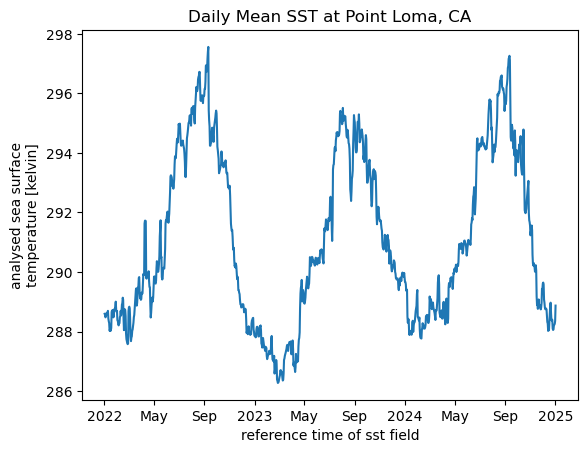

In [9]:
# Quick plot using xr plot one dimensional data array
time_series.plot()
plt.title('Daily Mean SST at Point Loma, CA')

## Export results

In [5]:
# Save the results as a csv
time_series_df = time_series.to_dataframe()
time_series_df.to_csv('data/MUR_SST_Point_Loma_mean_timeseries_2022-2025.csv')
time_series_df

,analysed_sst
time,
2022-01-01 09:00:00,288.595397
2022-01-02 09:00:00,288.554363
2022-01-03 09:00:00,288.475908
2022-01-04 09:00:00,288.517292
2022-01-05 09:00:00,288.572881
...,...
2024-12-28 09:00:00,288.209416
2024-12-29 09:00:00,288.226923
2024-12-30 09:00:00,288.257780
